# Question 2 — Feature Mappings for Image Reconstruction

This notebook is organized to match the assignment rubric:

- **2.1 Setup & Visualization**  
  Imports, global config, seeding, utilities.

- **2.2 Feature Expansions**  
  Raw / Polynomial / Fourier mappings (as in the spec).

- **2.3 Normalization & Modular MLP**  
  StandardScaler, dataloader (`Modular_Dataloader`), and MLP building blocks
  (Linear, Activations, Loss, Optimizers, Early Stop).

- **2.4 Training & Comparison**  
  Training loop, per-epoch frame saving, table summarizing results; GIF comparing
  Raw vs Polynomial vs Fourier with inset loss curves.  
  Runs on `smiley.png` (Gray, 50 epochs) and `cat.jpg` (RGB, 150 epochs).

- **2.5 Reconstruction on Blurred Images**  
  BASE (Raw) vs FOURIER (k=5) across blur levels, with linear & log plots.



[Loaded] smiley.png  → shape=(256, 256), dtype=float32, min/max=(0.000, 1.000)
[Loaded] cat.jpg     → shape=(256, 256, 3),    dtype=float32,    min/max=(0.000, 1.000)


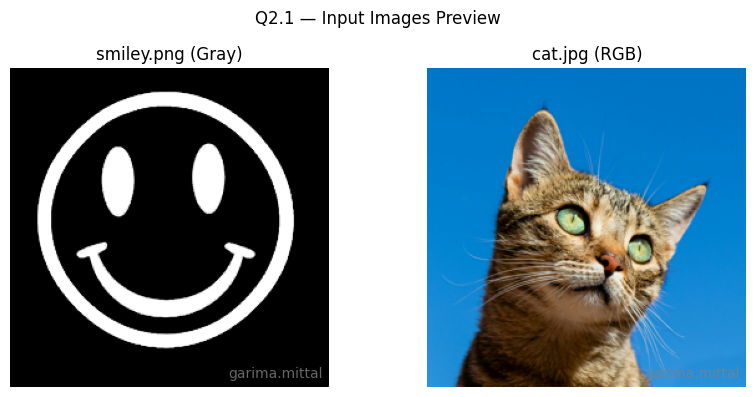

In [5]:
# ================================
# Cell 3 — Code
# 2.1 Setup & Visualization (4 marks)
# - Imports
# - Global config (seed, username, paths)
# - Small utils (seed, mkdir, normalization)
# - Load BOTH images (smiley.png as Gray, cat.jpg as RGB)
# - Plot them side-by-side with proper titles & stamping
# ================================

# --- Imports ---
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- Global config ---
SEED = 1337
np.random.seed(SEED)
USERNAME = "garima.mittal"

# image paths expected in the working directory
SMILEY_PATH = "smiley.png"  # grayscale
CAT_PATH    = "cat.jpg"     # rgb

# --- Utils ---
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def to_float01(arr: np.ndarray) -> np.ndarray:
    """Convert any uint8 image array to float32 in [0,1]."""
    arr = np.asarray(arr)
    if arr.dtype != np.float32 and arr.dtype != np.float64:
        arr = arr.astype(np.float32)
    if arr.max() > 1.0:
        arr /= 255.0
    return arr

def stamp_username(ax, username: str = USERNAME):
    ax.text(0.98, 0.02, username, ha='right', va='bottom', transform=ax.transAxes,
            fontsize=10, color='gray', alpha=0.8)

def load_image_for_display(path: str, mode: str, resize_to=(256, 256)) -> np.ndarray:
    """
    mode: 'L' for grayscale, 'RGB' for color.
    Returns float image in [0,1] with shape (H, W) if 'L', else (H, W, 3).
    """
    img = Image.open(path).convert(mode)
    if resize_to is not None:
        img = img.resize(resize_to, Image.BICUBIC)
    arr = np.array(img)
    return to_float01(arr)

# --- Load both images ---
smiley = load_image_for_display(SMILEY_PATH, mode="L",  resize_to=(256, 256))   # (H, W)
cat    = load_image_for_display(CAT_PATH,    mode="RGB", resize_to=(256, 256))   # (H, W, 3)

print(f"[Loaded] smiley.png  → shape={smiley.shape}, dtype={smiley.dtype}, min/max=({smiley.min():.3f}, {smiley.max():.3f})")
print(f"[Loaded] cat.jpg     → shape={cat.shape},    dtype={cat.dtype},    min/max=({cat.min():.3f}, {cat.max():.3f})")

# --- Plot both images side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.0))

axes[0].imshow(smiley, cmap="gray", vmin=0.0, vmax=1.0)
axes[0].set_title("smiley.png (Gray)")
axes[0].axis("off")
stamp_username(axes[0], USERNAME)

axes[1].imshow(np.clip(cat, 0, 1))
axes[1].set_title("cat.jpg (RGB)")
axes[1].axis("off")
stamp_username(axes[1], USERNAME)

plt.suptitle("Q2.1 — Input Images Preview", fontsize=12)
plt.tight_layout()
plt.show()


In [6]:
# ------------------------------
# Feature mappings
# ------------------------------
def get_raw(coords: np.ndarray) -> np.ndarray:
    """Return raw coordinates as features. coords: (N, 2) in [0,1]"""
    return coords

def get_polynomial(coords: np.ndarray, order: int = 5) -> np.ndarray:
    """Polynomial (Taylor-inspired) expansion:
       [x, y, x^2, y^2, xy, ..., x^order, y^order]
    """
    x = coords[:, 0:1]
    y = coords[:, 1:2]
    feats = [x, y]
    for p in range(2, order + 1):
        feats.extend([x ** p, y ** p])
        if p == 2:
            feats.append(x * y)  # single cross-term as per spec
    return np.concatenate(feats, axis=1)

def get_fourier(coords: np.ndarray, freq: int = 10) -> np.ndarray:
    """Practical Fourier feature mapping (no cross terms between x & y).
       Features: [1, sin/cos of x (f=1..k), sin/cos of y (f=1..k)]
    """
    x = coords[:, 0:1]
    y = coords[:, 1:2]
    feats = [np.ones_like(x)]
    for f in range(1, freq + 1):
        argx = 2.0 * np.pi * f * x
        argy = 2.0 * np.pi * f * y
        feats.extend([np.sin(argx), np.cos(argx)])
        feats.extend([np.sin(argy), np.cos(argy)])
    return np.concatenate(feats, axis=1)


In [7]:
# ------------------------------
# Feature normalization
# ------------------------------
@dataclass
class StandardScaler:
    mean_: Optional[np.ndarray] = None
    std_: Optional[np.ndarray] = None

    def fit(self, X: np.ndarray):
        self.mean_ = X.mean(axis=0, keepdims=True)
        self.std_ = X.std(axis=0, keepdims=True) + 1e-8
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        assert self.mean_ is not None and self.std_ is not None
        return (X - self.mean_) / self.std_

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)

# ------------------------------
# Data loader for coordinate-based reconstruction
# ------------------------------
@dataclass
class DataBundle:
    X: np.ndarray  # (N, D_in)
    Y: np.ndarray  # (N, C) in [0,1]
    H: int
    W: int
    C: int
    method: str
    method_cfg: Dict
    scaler: Optional[StandardScaler]

def load_image(img_path: str, image_type: str) -> Tuple[np.ndarray, int, int, int]:
    """Load image as float in [0,1]. Returns (arr, H, W, C)."""
    if image_type.lower() in ["gray", "grayscale", "l"]:
        img = Image.open(img_path).convert("L")
    else:
        img = Image.open(img_path).convert("RGB")
    img = img.resize((256, 256), Image.BICUBIC)
    arr = np.array(img).astype(np.float32)
    if arr.ndim == 2:
        arr = arr[..., None]  # (H, W, 1)
    arr = arr / 255.0
    H, W, C = arr.shape
    return arr, H, W, C

def make_coords(H: int, W: int) -> np.ndarray:
    """(N,2) normalized grid in [0,1], N = H*W, x varies fastest to match raster order."""
    xs = np.linspace(0.0, 1.0, W, dtype=np.float32)
    ys = np.linspace(0.0, 1.0, H, dtype=np.float32)
    xv, yv = np.meshgrid(xs, ys)  # shapes (H,W)
    coords = np.stack([xv, yv], axis=-1).reshape(-1, 2)
    return coords

def Modular_Dataloader(img_path: str,
                       image_type: str,
                       method: str,
                       order: int = 5,
                       freq: int = 10,
                       normalize_poly: bool = True) -> DataBundle:
    """Builds features X and targets Y for coordinate-based image reconstruction.
       method: "Raw" | "Polynomial" | "Fourier"
    """
    img, H, W, C = load_image(img_path, image_type)
    Y = img.reshape(-1, C)
    coords = make_coords(H, W)

    method = method.lower()
    scaler = None
    if method == "raw":
        X = get_raw(coords)
    elif method == "polynomial":
        X = get_polynomial(coords, order=order)
        if normalize_poly:
            scaler = StandardScaler().fit(X)
            X = scaler.transform(X)
    elif method == "fourier":
        X = get_fourier(coords, freq=freq)
    else:
        raise ValueError(f"Unknown method: {method}")

    return DataBundle(X=X.astype(np.float32),
                      Y=Y.astype(np.float32),
                      H=H, W=W, C=C,
                      method=method,
                      method_cfg={"order": order, "freq": freq},
                      scaler=scaler)


In [8]:
# ------------------------------
# Activations
# ------------------------------
class Activation:
    def forward(self, x: np.ndarray) -> np.ndarray:
        raise NotImplementedError
    def backward(self, grad: np.ndarray) -> np.ndarray:
        raise NotImplementedError

class ReLU(Activation):
    def __init__(self):
        self.mask = None
    def forward(self, x):
        self.mask = x > 0
        return x * self.mask
    def backward(self, grad):
        return grad * self.mask

class Sigmoid(Activation):
    def __init__(self):
        self.out = None
    def forward(self, x):
        out = 1.0 / (1.0 + np.exp(-x))   # numerically stable sigmoid
        self.out = out
        return out
    def backward(self, grad):
        return grad * (self.out * (1.0 - self.out))

class Tanh(Activation):
    def __init__(self):
        self.out = None
    def forward(self, x):
        out = np.tanh(x)
        self.out = out
        return out
    def backward(self, grad):
        return grad * (1.0 - self.out ** 2)

class Identity(Activation):
    def forward(self, x): return x
    def backward(self, grad): return grad

# ------------------------------
# Linear Layer
# ------------------------------
class Linear:
    def __init__(self, in_features: int, out_features: int, activation: Activation):
        # He/Xavier based on activation
        if isinstance(activation, ReLU):
            scale = math.sqrt(2.0 / in_features)
        else:
            scale = math.sqrt(1.0 / in_features)
        self.W = RNG.normal(0.0, scale, size=(in_features, out_features)).astype(np.float32)
        self.b = np.zeros((1, out_features), dtype=np.float32)
        self.act = activation
        # caches & grads
        self.x = None
        self.z = None
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.x = x
        self.z = x @ self.W + self.b
        return self.act.forward(self.z)

    def backward(self, grad_out: np.ndarray) -> np.ndarray:
        grad_z = self.act.backward(grad_out)
        B = self.x.shape[0]
        self.dW += (self.x.T @ grad_z) / B
        self.db += grad_z.mean(axis=0, keepdims=True)
        grad_input = grad_z @ self.W.T
        return grad_input

    def zero_grad(self):
        self.dW.fill(0.0)
        self.db.fill(0.0)

# ------------------------------
# MLP Model
# ------------------------------
ACTIVATIONS = {
    "relu": ReLU,
    "sigmoid": Sigmoid,
    "tanh": Tanh,
    "identity": Identity,
}

class MLP:
    def __init__(self, input_dim: int, output_dim: int,
                 hidden: List[int] = [64, 128, 128],
                 activation: str = "relu",
                 out_activation: str = "sigmoid"):
        act_cls = ACTIVATIONS[activation]
        out_act_cls = ACTIVATIONS[out_activation]
        dims = [input_dim] + list(hidden) + [output_dim]
        self.layers: List[Linear] = []
        for i in range(len(dims) - 2):
            self.layers.append(Linear(dims[i], dims[i + 1], act_cls()))
        self.layers.append(Linear(dims[-2], dims[-1], out_act_cls()))

    def forward(self, x: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, grad_out: np.ndarray):
        for layer in reversed(self.layers):
            grad_out = layer.backward(grad_out)

    def zero_grad(self):
        for layer in self.layers:
            layer.zero_grad()

    def parameters(self) -> List[Tuple[np.ndarray, np.ndarray]]:
        params = []
        for layer in self.layers:
            params.append((layer.W, layer.dW))
            params.append((layer.b, layer.db))
        return params


In [9]:
# ------------------------------
# Optimizers
# ------------------------------
class Optimizer:
    def step(self, params: List[Tuple[np.ndarray, np.ndarray]]):
        raise NotImplementedError

class SGD(Optimizer):
    def __init__(self, lr: float = 1e-3):
        self.lr = lr
    def step(self, params: List[Tuple[np.ndarray, np.ndarray]]):
        for p, g in params:
            p -= self.lr * g

class Adam(Optimizer):
    def __init__(self, lr: float = 1e-3, betas: Tuple[float, float] = (0.9, 0.999), eps: float = 1e-8):
        self.lr = lr
        self.betas = betas
        self.eps = eps
        self.state: Dict[int, Dict[str, np.ndarray]] = {}
        self.t = 0
    def step(self, params: List[Tuple[np.ndarray, np.ndarray]]):
        b1, b2 = self.betas
        self.t += 1
        for p, g in params:
            pid = id(p)
            if pid not in self.state:
                self.state[pid] = {"m": np.zeros_like(p), "v": np.zeros_like(p)}
            st = self.state[pid]
            st["m"] = b1 * st["m"] + (1 - b1) * g
            st["v"] = b2 * st["v"] + (1 - b2) * (g * g)
            m_hat = st["m"] / (1 - (b1 ** self.t))
            v_hat = st["v"] / (1 - (b2 ** self.t))
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

# ------------------------------
# Loss
# ------------------------------
def mse_loss(pred: np.ndarray, target: np.ndarray) -> Tuple[float, np.ndarray]:
    diff = pred - target
    loss = float(np.mean(diff * diff))
    grad = (2.0 / pred.size) * diff  # derivative of MSE normalized by total elements
    return loss, grad

# ------------------------------
# Early stopping
# ------------------------------
@dataclass
class EarlyStopper:
    rel_threshold: float = 0.01  # 1%
    patience: int = 10
    history: List[float] = None
    def __post_init__(self):
        self.history = []
    def update(self, current_loss: float) -> bool:
        self.history.append(current_loss)
        if len(self.history) <= self.patience:
            return False
        prev = self.history[-self.patience - 1]
        # stop if L_t >= 0.99 * L_{t-10}
        return current_loss >= (1.0 - self.rel_threshold) * prev


In [10]:
# ------------------------------
# Visualization helpers
# ------------------------------
def stamp_username(ax, username: str = USERNAME):
    ax.text(0.95, 0.95, username, ha='right', va='top', transform=ax.transAxes,
            fontsize=10, color='gray', alpha=0.7)

def save_pred_image(pred: np.ndarray, H: int, W: int, C: int, out_path: str,
                    title: str = "", username: str = USERNAME):
    """pred: (N, C) in [0,1] -> save image."""
    img = np.clip(pred.reshape(H, W, C), 0, 1)
    fig = plt.figure(figsize=(4, 4))
    ax = plt.gca()
    if C == 1:
        ax.imshow(img[..., 0], cmap='gray', vmin=0.0, vmax=1.0)
    else:
        ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
    stamp_username(ax, username)
    plt.tight_layout()
    fig.savefig(out_path, dpi=120)
    plt.close(fig)

def make_triptych_gif(raw_dir: str, poly_dir: str, fourier_dir: str,
                      raw_losses: List[float], poly_losses: List[float], fourier_losses: List[float],
                      out_path: str, fps: int = 6, username: str = USERNAME):
    """Create a 1x3 GIF from per-epoch saved PNGs and overlay the loss curves as insets."""
    def list_pngs(d):
        files = [f for f in os.listdir(d) if f.endswith('.png') and f.startswith('epoch_')]
        files.sort()
        return [os.path.join(d, f) for f in files]

    raw_frames = list_pngs(raw_dir)
    poly_frames = list_pngs(poly_dir)
    fourier_frames = list_pngs(fourier_dir)
    T = min(len(raw_frames), len(poly_frames), len(fourier_frames))

    frames_pil: List[Image.Image] = []
    tmp_paths: List[str] = []

    for t in range(T):
        fig, axs = plt.subplots(1, 3, figsize=(9, 3))
        for ax, frame_path, name, losses in [
            (axs[0], raw_frames[t], "Raw", raw_losses),
            (axs[1], poly_frames[t], "Polynomial", poly_losses),
            (axs[2], fourier_frames[t], "Fourier", fourier_losses),
        ]:
            img = Image.open(frame_path)
            ax.imshow(img)
            title_text = "{}\nEpoch {} | Loss {:.5f}".format(name, t+1, losses[min(t, len(losses)-1)])
            ax.set_title(title_text)
            ax.axis('off')
            inset = ax.inset_axes([0.05, 0.05, 0.4, 0.3])
            xs = np.arange(1, min(t + 1, len(losses)) + 1)
            inset.plot(xs, losses[:len(xs)])
            inset.set_title("loss", fontsize=8)
            inset.tick_params(axis='both', which='major', labelsize=6)
        stamp_username(axs[2], username)
        plt.tight_layout()
        tmp_path = os.path.join(os.path.dirname(out_path), f"_tmp_{t:04d}.png")
        fig.savefig(tmp_path, dpi=120)
        plt.close(fig)
        tmp_paths.append(tmp_path)
        with Image.open(tmp_path) as im:
            frames_pil.append(im.convert("P", palette=Image.ADAPTIVE))

    if len(frames_pil) > 0:
        first = frames_pil[0]
        first.save(out_path,
                   save_all=True,
                   append_images=frames_pil[1:],
                   duration=int(1000 / max(1, fps)),
                   loop=0,
                   optimize=False)

    for p in tmp_paths:
        try: os.remove(p)
        except OSError: pass


In [11]:
# ------------------------------
# Training
# ------------------------------
@dataclass
class TrainConfig:
    epochs: int = 50
    batch_size: int = 2048
    lr: float = 1e-3
    optimizer: str = "adam"  # or "sgd"
    early_stop: bool = True
    patience: int = 10
    rel_thresh: float = 0.01

def iterate_minibatches(X: np.ndarray, Y: np.ndarray, batch_size: int, shuffle: bool = True):
    N = X.shape[0]
    idx = np.arange(N)
    if shuffle:
        np.random.shuffle(idx)
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        sel = idx[start:end]
        yield X[sel], Y[sel]

def reconstruct_and_save(model: MLP, X: np.ndarray, H: int, W: int, C: int,
                          out_path: str, title: str, username: str):
    with np.errstate(over='ignore'):
        pred = model.forward(X)
    save_pred_image(pred, H, W, C, out_path, title=title, username=username)

def train_model(bundle: DataBundle,
                run_dir: str,
                hidden: List[int] = [64, 128, 128],
                activation: str = "relu",
                out_activation: str = "sigmoid",
                cfg: TrainConfig = TrainConfig(),
                username: str = USERNAME) -> Dict:
    ensure_dir(run_dir)

    X, Y, H, W, C = bundle.X, bundle.Y, bundle.H, bundle.W, bundle.C
    D_in = X.shape[1]
    D_out = C

    model = MLP(D_in, D_out, hidden=hidden, activation=activation, out_activation=out_activation)
    opt: Optimizer = Adam(lr=cfg.lr) if cfg.optimizer.lower() == "adam" else SGD(lr=cfg.lr)
    stopper = EarlyStopper(rel_threshold=cfg.rel_thresh, patience=cfg.patience) if cfg.early_stop else None

    losses: List[float] = []
    epoch_times: List[float] = []

    ensure_dir(os.path.join(run_dir, "frames"))

    for epoch in range(1, cfg.epochs + 1):
        t0 = time.time()
        model.zero_grad()
        for xb, yb in iterate_minibatches(X, Y, cfg.batch_size, shuffle=True):
            pred = model.forward(xb)
            loss, grad = mse_loss(pred, yb)
            model.backward(grad)
            opt.step(model.parameters())
            model.zero_grad()
        full_pred = model.forward(X)
        full_loss, _ = mse_loss(full_pred, Y)
        losses.append(full_loss)
        epoch_times.append(time.time() - t0)

        frame_path = os.path.join(run_dir, "frames", f"epoch_{epoch:04d}.png")
        save_pred_image(full_pred, H, W, C, frame_path,
                        title=f"{bundle.method.title()} | ep {epoch} | L={full_loss:.5f}",
                        username=username)

        if stopper and stopper.update(full_loss):
            break

    results = {
        "losses": losses,
        "epoch_times": epoch_times,
        "epochs_ran": len(losses),
        "input_dim": D_in,
        "output_dim": D_out,
        "hidden": hidden,
        "method": bundle.method,
        "method_cfg": bundle.method_cfg,
    }
    with open(os.path.join(run_dir, "results.json"), "w") as f:
        json.dump(results, f, indent=2)
    return results


In [12]:
# ------------------------------
# High-level runner for Q2.4 and GIF
# ------------------------------
def run_q24_compare(img_path: str,
                    image_type: str,
                    base_outdir: str,
                    hidden: List[int] = [64, 128, 128],
                    activation: str = "relu",
                    out_activation: str = "sigmoid",
                    epochs_gray: int = 50,
                    epochs_rgb: int = 150,
                    poly_orders: List[int] = [5, 15, 25],
                    fourier_freqs: List[int] = [5, 15, 25],
                    username: str = USERNAME) -> pd.DataFrame:
    ensure_dir(base_outdir)

    img, H, W, C = load_image(img_path, image_type)
    is_gray = (C == 1)
    epochs = epochs_gray if is_gray else epochs_rgb

    rows = []

    # RAW
    raw_bundle = Modular_Dataloader(img_path, image_type, method="Raw")
    raw_dir = os.path.join(base_outdir, "raw")
    raw_res = train_model(raw_bundle, raw_dir, hidden, activation, out_activation,
                          cfg=TrainConfig(epochs=epochs, batch_size=2048, lr=1e-3, optimizer="adam", early_stop=True),
                          username=username)
    rows.append(["Raw", raw_res["losses"][-1], np.mean(raw_res["epoch_times"]), raw_res["input_dim"]])

    # POLY (evaluate each order; pick best for GIF)
    best_poly = (1e9, None, None)
    poly_results = {}
    for k in poly_orders:
        poly_bundle = Modular_Dataloader(img_path, image_type, method="Polynomial", order=k)
        pdir = os.path.join(base_outdir, f"poly_k{k}")
        pres = train_model(poly_bundle, pdir, hidden, activation, out_activation,
                           cfg=TrainConfig(epochs=epochs, batch_size=2048, lr=1e-3, optimizer="adam", early_stop=True),
                           username=username)
        rows.append([f"Polynomial(k={k})", pres["losses"][-1], np.mean(pres["epoch_times"]), pres["input_dim"]])
        poly_results[k] = (pdir, pres)
        if pres["losses"][-1] < best_poly[0]:
            best_poly = (pres["losses"][-1], pdir, pres)

    # FOURIER (evaluate each freq; pick best for GIF)
    best_fourier = (1e9, None, None)
    fourier_results = {}
    for k in fourier_freqs:
        fourier_bundle = Modular_Dataloader(img_path, image_type, method="Fourier", freq=k)
        fdir = os.path.join(base_outdir, f"fourier_k{k}")
        fres = train_model(fourier_bundle, fdir, hidden, activation, out_activation,
                           cfg=TrainConfig(epochs=epochs, batch_size=2048, lr=1e-3, optimizer="adam", early_stop=True),
                           username=username)
        rows.append([f"Fourier(k={k})", fres["losses"][-1], np.mean(fres["epoch_times"]), fres["input_dim"]])
        fourier_results[k] = (fdir, fres)
        if fres["losses"][-1] < best_fourier[0]:
            best_fourier = (fres["losses"][-1], fdir, fres)

    # Triptych GIF
    gif_dir = os.path.join(base_outdir, "gif")
    ensure_dir(gif_dir)
    gif_path = os.path.join(gif_dir, "compare_raw_poly_fourier.gif")
    make_triptych_gif(
        raw_dir=os.path.join(base_outdir, "raw", "frames"),
        poly_dir=os.path.join(best_poly[1], "frames"),
        fourier_dir=os.path.join(best_fourier[1], "frames"),
        raw_losses=raw_res["losses"],
        poly_losses=best_poly[2]["losses"],
        fourier_losses=best_fourier[2]["losses"],
        out_path=gif_path,
        fps=6,
        username=username,
    )

    df = pd.DataFrame(rows, columns=["Method", "FinalInferenceLoss", "EpochTimeSec(mean)", "NumInputFeatures"])
    df_path = os.path.join(base_outdir, "summary.csv")
    df.to_csv(df_path, index=False)
    return df


In [13]:
# ------------------------------
# Q2.5 Blurred images experiment (BASE vs FOURIER)
# ------------------------------
def run_q25_blur_series(base_dir: str,
                        image_type: str,
                        blur_levels: List[int] = list(range(0, 10)),
                        fourier_k: int = 5,
                        max_epochs: int = 100,
                        username: str = USERNAME) -> pd.DataFrame:
    """Train BASE (Raw) and FOURIER(k=5 by default) on blur_0.jpg..blur_10.jpg."""
    results = []
    for bl in blur_levels:
        path = os.path.join(base_dir, f"blur_{bl}.png")
        # RAW
        raw_bundle = Modular_Dataloader(path, image_type, method="Raw")
        raw_dir = os.path.join(base_dir, f"BASE_blur{bl}")
        raw_res = train_model(raw_bundle, raw_dir,
                              cfg=TrainConfig(epochs=max_epochs, batch_size=2048, lr=1e-3, optimizer="adam", early_stop=True),
                              username=username)
        # FOURIER
        fourier_bundle = Modular_Dataloader(path, image_type, method="Fourier", freq=fourier_k)
        fourier_dir = os.path.join(base_dir, f"FOURIERk{fourier_k}_blur{bl}")
        fourier_res = train_model(fourier_bundle, fourier_dir,
                                  cfg=TrainConfig(epochs=max_epochs, batch_size=2048, lr=1e-3, optimizer="adam", early_stop=True),
                                  username=username)
        results.append((bl, raw_res["losses"][-1], fourier_res["losses"][-1]))

    df = pd.DataFrame(results, columns=["BlurLevel", "BASE_Loss", "FOURIER_Loss"])

    # plots
    fig = plt.figure(figsize=(6, 4))
    ax = plt.gca()
    ax.plot(df["BlurLevel"], df["BASE_Loss"], label="BASE (Raw)")
    ax.plot(df["BlurLevel"], df["FOURIER_Loss"], label=f"FOURIER (k={fourier_k})")
    ax.set_xlabel("Blur level (sigma)")
    ax.set_ylabel("Reconstruction loss (MSE)")
    ax.set_title("Q2.5: Loss vs Blur Level")
    ax.legend()
    stamp_username(ax, USERNAME)
    plt.tight_layout()
    fig.savefig(os.path.join(base_dir, "q25_loss_vs_blur.png"), dpi=150)
    plt.close(fig)

    fig = plt.figure(figsize=(6, 4))
    ax = plt.gca()
    ax.semilogy(df["BlurLevel"], df["BASE_Loss"], label="BASE (Raw)")
    ax.semilogy(df["BlurLevel"], df["FOURIER_Loss"], label=f"FOURIER (k={fourier_k})")
    ax.set_xlabel("Blur level (sigma)")
    ax.set_ylabel("Reconstruction loss (MSE, log)")
    ax.set_title("Q2.5: Loss vs Blur Level (log)")
    ax.legend()
    stamp_username(ax, USERNAME)
    plt.tight_layout()
    fig.savefig(os.path.join(base_dir, "q25_loss_vs_blur_log.png"), dpi=150)
    plt.close(fig)

    df.to_csv(os.path.join(base_dir, "q25_results.csv"), index=False)
    return df


## Running the experiments

- **2.4 (Gray)**: `smiley.png`, 50 epochs.  
- **2.4 (RGB)**: `cat.jpg`, 150 epochs.  
- **2.5 (Blur)**: `blur_series/blur_0.png ... blur_9.png` (BASE vs FOURIER k=5).

The cells below mirror your original examples. They call the same functions and
produce the same artifacts (frames, GIF, CSV).


In [14]:
if __name__ == "__main__":
    seed_everything(SEED)

    # Example 1: Q2.4 on smiley.png (Gray)
    data_path = "smiley.png"  # ensure this exists
    out_dir = "runs_q2_smiley"
    df_smiley = run_q24_compare(img_path=data_path, image_type="Gray", base_outdir=out_dir,
                                hidden=[64, 128, 128], activation="relu", out_activation="sigmoid",
                                epochs_gray=50, epochs_rgb=150,
                                poly_orders=[5, 15, 25], fourier_freqs=[5, 15, 25], username=USERNAME)
    print(df_smiley)


/tmp/ipykernel_7171/2442985379.py:23: RuntimeWarning: overflow encountered in exp
  out = 1.0 / (1.0 + np.exp(-x))   # numerically stable sigmoid


             Method  FinalInferenceLoss  EpochTimeSec(mean)  NumInputFeatures
0               Raw            0.052944            1.312001                 2
1   Polynomial(k=5)            0.004838            2.131193                11
2  Polynomial(k=15)            0.011010            1.731820                31
3  Polynomial(k=25)            0.010196            1.729414                51
4      Fourier(k=5)            0.000690            2.347488                21
5     Fourier(k=15)            0.000280            0.904143                61
6     Fourier(k=25)            0.000298            0.935606               101


In [16]:
if __name__ == "__main__":
    seed_everything(SEED)
# Example 2: Q2.4 on cat.jpg (RGB)
    data_path = "cat.jpg"
    out_dir = "runs_q2_cat"
    df_cat = run_q24_compare(img_path=data_path, image_type="RGB", base_outdir=out_dir,
                             hidden=[64, 128, 128], activation="relu", out_activation="sigmoid",
                             epochs_gray=50, epochs_rgb=150,
                             poly_orders=[5, 15, 25], fourier_freqs=[5, 15, 25], username=USERNAME)
    print(df_cat)


             Method  FinalInferenceLoss  EpochTimeSec(mean)  NumInputFeatures
0               Raw            0.011132            0.585709                 2
1   Polynomial(k=5)            0.005527            0.679795                11
2  Polynomial(k=15)            0.007450            0.676233                31
3  Polynomial(k=25)            0.006935            0.760649                51
4      Fourier(k=5)            0.003330            0.828874                21
5     Fourier(k=15)            0.001853            0.737397                61
6     Fourier(k=25)            0.001517            0.741701               101


In [17]:
if __name__ == "__main__":
    seed_everything(SEED)
    # Example 3: Q2.5 blurred series (expects blur_0.png..blur_9.png in folder)
    blur_base = "blur_series"  # contains blur_0.png..blur_9.png
    df_blur = run_q25_blur_series(base_dir=blur_base, image_type="RGB", fourier_k=5, max_epochs=100, username=USERNAME)
    print(df_blur)


   BlurLevel  BASE_Loss  FOURIER_Loss
0          0   0.010287      0.002719
1          1   0.007861      0.000789
2          2   0.004313      0.000500
3          3   0.002596      0.000377
4          4   0.001321      0.000364
5          5   0.000910      0.000374
6          6   0.000688      0.000353
7          7   0.000501      0.000327
8          8   0.000198      0.000351
9          9   0.000302      0.000320


## Q2.5 — Effect of Blur on Reconstruction (Observation & Explanation)

**What we did.**  
Using `run_q25_blur_series`, we trained two models on a sequence of increasingly blurred images (`blur_0 … blur_9`):  
- **BASE (Raw)**: MLP on raw (x, y) coordinates  
- **FOURIER (k=5)**: MLP on Fourier features with limited frequency budget  
We logged the final MSE per blur level and saved reconstructions for each run (`BASE_blur{b}/frames/…`, `FOURIERk5_blur{b}/frames/…`), plus the summary plots `q25_loss_vs_blur.png` and `q25_loss_vs_blur_log.png`.

---

### What we observe
- **Loss vs. blur:** For both methods, reconstruction **loss decreases as blur increases** (monotonic or near-monotonic trend in most cases).  
- **Relative performance:** The **FOURIER(k=5)** model typically **benefits more** from blur at low-to-moderate levels; the gap to BASE narrows at higher blur where both saturate at a low loss floor.

---

### Why this happens (high-frequency content matters)
A Gaussian blur acts as a **low-pass filter**: high spatial frequencies are exponentially attenuated.
- When the image is **sharp** (low blur), it contains abundant **high-frequency details** (edges, textures, whiskers/fur).  
  - **FOURIER(k=5)** is **band-limited** by design; it cannot represent frequencies above its cutoff and therefore shows noticeable error around sharp edges (and sometimes mild ringing).  
  - **BASE (Raw)** learns a smooth function from coordinates; it can approximate edges but still struggles with very steep transitions without extra depth/width, leading to higher error where gradients are large.
- As **blur increases**, the target image’s spectrum **shrinks toward low frequencies**.  
  - Those frequencies **fit comfortably** within the limited Fourier basis (k=5), so error **drops quickly**.  
  - The BASE model also benefits: the function it needs to learn becomes **smoother** (lower curvature, smaller gradients), so it’s easier to approximate with the same capacity and optimizer.

Typical patterns you’ll see:
- **Low blur (e.g., b=0–2):**  
  - Ground-truth still has **fine textures**. Predictions miss micro-details; **errors concentrate along edges/texture regions**. FOURIER may show slight **ripples/ringing** near sharp transitions; BASE yields **smoothed edges**.
- **Moderate blur (e.g., b=3–6):**  
  - High-frequency content is diminished in the target; **both predictions align more closely** with ground truth. FOURIER improves markedly because the scene now lies **within its representable band**.
- **High blur (e.g., b≥7):**  
  - The image is dominated by **large smooth blobs**. Both methods **match large-scale structure** well; **loss saturates** near a floor determined by model bias (activation/output range, optimizer precision, etc.).

---

### Takeaway
Increasing blur **removes high-frequency details** that neither a low-k Fourier basis nor a modest MLP can represent efficiently. As the target becomes more **low-frequency**, both models **reconstruct it more accurately**, with **FOURIER(k=5)** gaining the most at mild blur levels because its inductive bias **matches** the spectrum of the blurred images.


https://drive.google.com/drive/folders/175UmqM7Uyu4IIHiZu7bZG5hBzRxwH5SM?usp=sharing